# Phase 9 — Head-to-Head: v1 (propensity) vs v2 (uplift) policy

**The gap this closes.** Phase 6 shipped the **v1 targeted policy** — propensity-based,
using a fixed uplift assumption. Phase 8 built the **v2 uplift model** — causal,
per-user learned lift. But nothing yet has actually *run* both policies side-by-side
to quantify the incremental business value of the causal work.

This notebook does exactly that, using the simulator's ground-truth `true_uplift`
column (only available in the experimental dataset) as the arbiter. Both policies
operate on the **same lever** (`credit_5`) so the comparison is apples-to-apples.

**The three policies compared:**

1. **Blanket** — today's campaign: everyone at tenure = 11 months gets `credit_5`
2. **v1 propensity** — target if `P(churn) × 0.15 × LTV − $5 > 0`, subject to budget
3. **v2 uplift** — target if `learned_uplift(user, credit_5) × LTV − $5 > 0`, subject to budget

## Sections

| Section | Purpose |
|---|---|
| **A. Setup** | Load both models, score all subscribers |
| **B. Run the three policies** | Same budget cap, same lever |
| **C. Overlap analysis** | Who does each policy target? Where do they disagree? |
| **D. Ground-truth EV** | Score both against the simulator's true_uplift |
| **E. Sleeping-dog analysis** | What fraction of each policy's target set is a sleeping dog? |
| **F. Head-to-head chart** | Blanket → v1 → v2 summary |
| **G. Verdict + memo addendum** | Recommendation for stakeholders |

All figures saved under `reports/figures/`.

In [1]:
import os
import sys
import warnings
from pathlib import Path

# Silence two harmless third-party warnings triggered by loading the
# scikit-uplift model. Same rationale as Phase 8; clears itself when
# sklift releases a version compatible with sklearn 1.8+ and modern
# ipywidgets. Not our code.
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    message="Function stable_cumsum is deprecated",
)
warnings.filterwarnings(
    "ignore",
    message=".*IProgress not found.*",
)

try:
    _project_root = Path(__file__).resolve().parents[1]
except NameError:
    _here = Path.cwd()
    _project_root = _here.parent if _here.name == "notebooks" else _here
os.chdir(_project_root)
sys.path.insert(0, str(_project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.loader import load_subscribers_experiment
from src.features.transforms import build_features
from src.models.train import prepare_features
from src.models.production import (
    load_production_churn_model, load_production_uplift_model,
    UPLIFT_FOCUS_LEVER,
)
from src.decisions.policy import (
    INTERVENTION_MENU, LTV_BY_TIER,
    pick_best_lever, pick_best_lever_uplift, apply_budget_cap,
    summarize_policy, simulate_blanket_campaign,
)

FIG_DIR = Path("reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Both policies operate on the SAME lever (credit_5) so the comparison is
# apples-to-apples. Phase 8's uplift model is trained only for credit_5;
# extending to multi-lever uplift is a v1.1 followup.
LEVER = UPLIFT_FOCUS_LEVER
BUDGET = 200_000.0

## A. Setup — load models, score all subscribers

Use the experimental dataset because it contains the ground-truth `true_uplift`
column we need in Section D. Scoring only uses the standard features (the treatment
columns are held aside for validation).

In [2]:
print("=" * 70)
print(f"A. SETUP  (lever: {LEVER}, budget: ${BUDGET:,.0f})")
print("=" * 70)

raw = load_subscribers_experiment("data/subscribers_experiment.csv")
df = build_features(raw)
X, y = prepare_features(df)

# Load the two production models
churn_model, churn_artifact = load_production_churn_model()
uplift_model, uplift_artifact = load_production_uplift_model()
X_churn = X[churn_artifact["feature_names"]]
X_uplift = X[uplift_artifact["feature_names"]]

p_churn = churn_model.predict_proba(X_churn)[:, 1]
# sklift returns uplift as P(Y=1|T=1) - P(Y=1|T=0). Y=1 = churn, so a
# retention-positive treatment has NEGATIVE churn uplift. Flip sign so
# "positive lift = churn reduced" for the rest of this notebook.
predicted_retention_lift = -uplift_model.predict(X_uplift)

ltv = df["plan_tier"].map(LTV_BY_TIER).values
tenure = df["tenure_months"].values
true_uplift = df["true_uplift"].values   # simulator ground truth
treated = df["treated"].values
treatment_lever = df["treatment_lever"].values   # which lever each treated user got

print(f"Scored {len(df):,} subscribers with both models")
print(f"  Churn model: mean P(churn) = {p_churn.mean():.4f}, "
      f"p90 = {np.percentile(p_churn, 90):.4f}")
print(f"  Uplift model: mean pred lift = {predicted_retention_lift.mean():+.4f}, "
      f"max = {predicted_retention_lift.max():+.4f}")

A. SETUP  (lever: credit_5, budget: $200,000)
Scored 50,000 subscribers with both models
  Churn model: mean P(churn) = 0.0519, p90 = 0.1125
  Uplift model: mean pred lift = +0.0361, max = +0.4866


## B. Run all three policies

Same budget cap ($200k), same lever (`credit_5`). Only the *targeting rule* differs.

**Caveat vs the memo's blanket number.** The decision memo reports a blanket-baseline
net EV of **−$4.8k** — computed under Phase 6's full 3-lever menu (curated_playlist +
credit_5 + premium_upgrade). This notebook restricts blanket / v1 / v2 to `credit_5`
**only**, so all three policies decide the same question ("send credit_5 or not?"). The
blanket numbers here therefore won't match the memo's — different scope, same intent.
The head-to-head *between* the policies is the point; matching the memo's absolute
blanket EV isn't.

In [3]:
print("\n" + "=" * 70)
print("B. RUN THE THREE POLICIES")
print("=" * 70)

# Restrict the menu to the focus lever so v1 and v2 are apples-to-apples
single_lever_menu = {LEVER: INTERVENTION_MENU[LEVER]}
LEVER_COST = INTERVENTION_MENU[LEVER]["cost"]
LEVER_UPLIFT = INTERVENTION_MENU[LEVER]["uplift"]

# --- Blanket baseline (today's state) --------------------------------
blanket = simulate_blanket_campaign(
    p_churn=p_churn, ltv=ltv, tenure_months=tenure,
    cost_per_user=LEVER_COST, target_month=11, uplift=LEVER_UPLIFT,
)
blanket_mask = tenure == 11

# --- v1 propensity policy --------------------------------------------
v1_policy = pick_best_lever(p_churn, ltv, single_lever_menu)
v1_policy = apply_budget_cap(v1_policy, budget=BUDGET)
v1_summary = summarize_policy(v1_policy, targeted_only=True)
v1_mask = v1_policy["will_target"].values

# --- v2 uplift policy ------------------------------------------------
v2_policy = pick_best_lever_uplift(
    uplift_by_lever={LEVER: predicted_retention_lift},
    ltv=ltv,
    menu=single_lever_menu,
)
v2_policy = apply_budget_cap(v2_policy, budget=BUDGET)
v2_summary = summarize_policy(v2_policy, targeted_only=True)
v2_mask = v2_policy["will_target"].values

print(f"\n{'':16} {'Users targeted':>15} {'Cost':>12} {'Net EV':>12} {'ROI':>8}")
print("-" * 68)
print(f"{'Blanket m11':<16} {blanket['n_targeted']:>15,} "
      f"${blanket['total_cost']:>10,.0f} ${blanket['net_expected_value']:>10,.0f} "
      f"{blanket['roi_multiplier']:>7.2f}x")
print(f"{'v1 propensity':<16} {v1_summary['n_targeted']:>15,} "
      f"${v1_summary['total_cost']:>10,.0f} ${v1_summary['net_expected_value']:>10,.0f} "
      f"{v1_summary['roi_multiplier']:>7.2f}x")
print(f"{'v2 uplift':<16} {v2_summary['n_targeted']:>15,} "
      f"${v2_summary['total_cost']:>10,.0f} ${v2_summary['net_expected_value']:>10,.0f} "
      f"{v2_summary['roi_multiplier']:>7.2f}x")

# --- EV-break-even threshold math: why v1 and v2 target so differently ----
# v1 and v2 use different EV formulas, so their "positive-EV" thresholds
# have different SHAPES. Print the per-tier break-even for each policy so
# the target-count gap is defensible arithmetic, not a mystery.
print(f"\n{'-' * 68}")
print(f"Why the target-count gap? Different EV formulas -> different thresholds:")
print(f"{'-' * 68}")
print(f"  v1 EV formula:  P(churn) x {LEVER_UPLIFT:.0%} x LTV - ${LEVER_COST:.0f}")
print(f"    -> positive EV requires  P(churn) > ${LEVER_COST:.0f} / "
      f"({LEVER_UPLIFT:.0%} x LTV)")
print(f"  v2 EV formula:  predicted_lift x LTV - ${LEVER_COST:.0f}")
print(f"    -> positive EV requires  predicted_lift > ${LEVER_COST:.0f} / LTV")
print()
print(f"  Per-tier activation thresholds:")
print(f"    {'Tier':<10} {'LTV':>7} {'v1: P(churn) >':>17} {'v2: lift >':>15}")
print(f"    {'-'*10} {'-'*7} {'-'*17} {'-'*15}")
for tier, tier_ltv in LTV_BY_TIER.items():
    v1_thresh = LEVER_COST / (LEVER_UPLIFT * tier_ltv)
    v2_thresh = LEVER_COST / tier_ltv
    print(f"    {tier:<10} ${tier_ltv:>5.0f}  {v1_thresh:>16.1%} "
          f"{v2_thresh:>14.1%}")
print(f"""
  Read: v1 needs users at moderate-to-high churn probability (~8-17%) to
  activate. v2 needs only a small positive predicted retention lift (~1-3%).
  The wider v2 target set (~{v2_summary['n_targeted']/max(v1_summary['n_targeted'],1):.1f}x v1) reflects the uplift model
  finding the 'persuadable middle' -- users at modest churn risk but high
  responsiveness that v1's high-risk-first rule filters out.
""")


B. RUN THE THREE POLICIES

                  Users targeted         Cost       Net EV      ROI
--------------------------------------------------------------------
Blanket m11                1,587 $     7,935 $    -4,798    0.40x
v1 propensity              4,732 $    23,660 $    14,953    1.63x
v2 uplift                 29,867 $   149,335 $   305,263    3.04x

--------------------------------------------------------------------
Why the target-count gap? Different EV formulas -> different thresholds:
--------------------------------------------------------------------
  v1 EV formula:  P(churn) x 15% x LTV - $5
    -> positive EV requires  P(churn) > $5 / (15% x LTV)
  v2 EV formula:  predicted_lift x LTV - $5
    -> positive EV requires  predicted_lift > $5 / LTV

  Per-tier activation thresholds:
    Tier           LTV    v1: P(churn) >      v2: lift >
    ---------- ------- ----------------- ---------------
    Basic      $  200             16.7%           2.5%
    Standard   $  315

## C. Overlap analysis — where do v1 and v2 disagree?

**v1 ∩ v2** = users both policies target (agreement)
**v1 \\ v2** = users v1 targets but v2 skips — v2 thinks they won't respond
**v2 \\ v1** = users v2 targets but v1 misses — persuadables v1 can't see
(their absolute churn risk is modest but their responsiveness is high)

In [4]:
print("\n" + "=" * 70)
print("C. OVERLAP ANALYSIS")
print("=" * 70)

both = v1_mask & v2_mask
v1_only = v1_mask & ~v2_mask
v2_only = ~v1_mask & v2_mask
neither = ~v1_mask & ~v2_mask

print(f"\n{'Set':<32} {'Users':>10} {'% of base':>12}")
print("-" * 58)
print(f"{'Both v1 AND v2 target':<32} {both.sum():>10,} {both.mean():>11.2%}")
print(f"{'v1 only (v2 skips)':<32} {v1_only.sum():>10,} {v1_only.mean():>11.2%}")
print(f"{'v2 only (v1 misses)':<32} {v2_only.sum():>10,} {v2_only.mean():>11.2%}")
print(f"{'Neither':<32} {neither.sum():>10,} {neither.mean():>11.2%}")

# Diagnostic: what characterizes each disagreement set?
if v1_only.sum() > 0:
    print(f"\nv1-only users (v2 correctly skips): "
          f"mean true_uplift = {true_uplift[v1_only].mean():+.4f}  "
          f"(vs base rate {true_uplift.mean():+.4f})")
if v2_only.sum() > 0:
    print(f"v2-only users (v1 misses):          "
          f"mean true_uplift = {true_uplift[v2_only].mean():+.4f}  "
          f"(vs base rate {true_uplift.mean():+.4f})")
if both.sum() > 0:
    print(f"Both target:                        "
          f"mean true_uplift = {true_uplift[both].mean():+.4f}")


C. OVERLAP ANALYSIS

Set                                   Users    % of base
----------------------------------------------------------
Both v1 AND v2 target                 4,486       8.97%
v1 only (v2 skips)                      246       0.49%
v2 only (v1 misses)                  25,381      50.76%
Neither                              19,887      39.77%

v1-only users (v2 correctly skips): mean true_uplift = +0.0515  (vs base rate +0.0498)
v2-only users (v1 misses):          mean true_uplift = +0.0504  (vs base rate +0.0498)
Both target:                        mean true_uplift = +0.0560


## D. Ground-truth EV — score both policies against the simulator's truth

The killer feature of synthetic data: we know each user's *true* per-user uplift.
So for any targeting decision, we can compute what the treatment *would actually*
have delivered in expectation:

`actual_expected_retention = true_uplift × LTV`

Summing this across the targeted set gives the **true retained revenue** each policy
would have generated. Compare to the assumed retained revenue in Section B — the
gap tells us how much of the reported EV is real vs how much is over-claim.

### Two fairness caveats worth naming

**1. Lever-matching.** The uplift model was trained specifically for `credit_5`, so
`true_uplift` from the simulator is only interpretable for users who were actually
assigned `credit_5` in the experiment. Users assigned other levers have `true_uplift`
values that reflect THAT lever's effect, not `credit_5`. We restrict the observed
subset to `treated == 1 AND treatment_lever == credit_5` so the ground truth we
score against is the ground truth for the lever v2 was trained for. Earlier
iterations used `treated == 1` alone, which mixed levers and diluted the story.

**2. In-sample overlap (acknowledged, not fixed).** Both models have training-set
overlap with the users we're evaluating on:

- Phase 4 (churn model) trained on ~80% of all users (train + calib splits)
- Phase 8 (uplift model) trained on ~70% of the control + credit_5 subset

So the head-to-head is "each model at its best on shared users," not "each model on
strictly held-out data." A rigorous OOS-only comparison would restrict to the ~50
users held out from both models — too small a sample for reliable inference. Real
deployment should use a fresh randomized holdout for validation. The comparison is
still informative — same evaluation set, same lever, same budget cap — but not
purely OOS.

In [5]:
print("\n" + "=" * 70)
print("D. GROUND-TRUTH EV (against simulator's true_uplift)")
print("=" * 70)


# Ground-truth EV: restrict to users who were treated with the FOCUS_LEVER
# specifically. Their true_uplift is the ground-truth uplift for credit_5
# (the lever the uplift model was trained to predict). Users treated with
# other levers have true_uplift values that reflect those other levers --
# mixing them dilutes the comparison.
observed = (treated == 1) & (treatment_lever == LEVER)
n_obs = int(observed.sum())
n_all_treated = int((treated == 1).sum())
print(f"\nNote: ground-truth EV uses the {n_obs:,} users treated specifically with"
      f" {LEVER}.")
print(f"      ({n_all_treated:,} total treated users in the experiment, but only")
print(f"       {LEVER}-treated ones have credit_5-relevant ground truth.)")
print(f"For each policy, we ask: of those users, how many did the policy target,")
print(f"and what did their true_uplift × LTV sum to?\n")


def observed_gt_summary(mask, label):
    """Summarize a policy's targeting on the observed-treated subset.

    Persuadable = user whose treatment is intervention-worthy on ground
    truth, i.e., their true retained revenue exceeds the lever cost:
        true_uplift * LTV > LEVER_COST
    This uses per-user LTV and the actual lever cost (matches Phase 8's
    EV-break-even threshold — no arbitrary 0.02 hardcode).

    Sleeping dog = user whose treatment INCREASES churn (true_uplift < 0).
    """
    m = mask & observed
    n = int(m.sum())
    cost = n * LEVER_COST
    actual = float((true_uplift[m] * ltv[m]).sum())
    # Per-user EV break-even: user is a persuadable if their true
    # per-user retained revenue exceeds the lever cost
    intervention_worthy = (true_uplift * ltv) > LEVER_COST
    return {
        "policy": label,
        "n_targeted_observed": n,
        "cost": cost,
        "true_retained": actual,
        "true_net_ev": actual - cost,
        "true_roi": actual / cost if cost > 0 else 0.0,
        "persuadables": int((m & intervention_worthy).sum()),
        "sleeping_dogs": int((m & (true_uplift < 0)).sum()),
    }


rows = [
    observed_gt_summary(blanket_mask, "Blanket m11"),
    observed_gt_summary(v1_mask, "v1 propensity"),
    observed_gt_summary(v2_mask, "v2 uplift"),
]
gt_df = pd.DataFrame(rows)
print(gt_df.to_string(index=False))

print(f"\n>>> v2 vs v1 (on observed treated users):")
delta_retained = rows[2]["true_retained"] - rows[1]["true_retained"]
delta_ev = rows[2]["true_net_ev"] - rows[1]["true_net_ev"]
v1_precision = rows[1]["persuadables"] / max(rows[1]["n_targeted_observed"], 1)
v2_precision = rows[2]["persuadables"] / max(rows[2]["n_targeted_observed"], 1)
v1_dog_rate = rows[1]["sleeping_dogs"] / max(rows[1]["n_targeted_observed"], 1)
v2_dog_rate = rows[2]["sleeping_dogs"] / max(rows[2]["n_targeted_observed"], 1)
print(f"    Δ true retained revenue: ${delta_retained:+,.2f}")
print(f"    Δ true net EV:           ${delta_ev:+,.2f}")
print(f"    v1 precision (persuadables / targeted):     {v1_precision:.1%}")
print(f"    v2 precision (persuadables / targeted):     {v2_precision:.1%}")
print(f"    v1 sleeping-dog rate:                       {v1_dog_rate:.1%}")
print(f"    v2 sleeping-dog rate:                       {v2_dog_rate:.1%}")


D. GROUND-TRUTH EV (against simulator's true_uplift)

Note: ground-truth EV uses the 25,054 users treated specifically with credit_5.
      (25,054 total treated users in the experiment, but only
       credit_5-treated ones have credit_5-relevant ground truth.)
For each policy, we ask: of those users, how many did the policy target,
and what did their true_uplift × LTV sum to?

       policy  n_targeted_observed    cost  true_retained  true_net_ev  true_roi  persuadables  sleeping_dogs
  Blanket m11                  784  3920.0       21179.50     17259.50  5.402934           747             37
v1 propensity                 2386 11930.0       83858.92     71928.92  7.029247          2257            129
    v2 uplift                14969 74845.0      463242.46    388397.46  6.189357         14204            765

>>> v2 vs v1 (on observed treated users):
    Δ true retained revenue: $+379,383.54
    Δ true net EV:           $+316,468.54
    v1 precision (persuadables / targeted):     94

## E. Sleeping-dog analysis

Sleeping dogs = users whose `true_uplift < 0` (treatment *increases* their churn).
The interesting question isn't just "how many does each policy target" (which scales
with total volume) but "**what fraction** of what each policy targets is a sleeping
dog?" — the sleeping-dog rate. A model that beats random targeting has a sleeping-dog
rate BELOW the population base rate.

In [6]:
print("\n" + "=" * 70)
print("E. SLEEPING-DOG ANALYSIS")
print("=" * 70)

sleeping = (true_uplift < 0) & observed
total_dogs = int(sleeping.sum())
base_rate = total_dogs / int(observed.sum())
print(f"\nTotal sleeping dogs in observed treated set: {total_dogs:,} "
      f"({base_rate:.1%} of observed pool -- the random-targeting base rate)")

print(f"\n{'Policy':<18} {'Targeted (obs)':>15} {'SD hit':>8} {'SD rate':>10} "
      f"{'vs. random':>12}")
print("-" * 66)
for label, mask in [("Blanket m11", blanket_mask),
                    ("v1 propensity", v1_mask),
                    ("v2 uplift", v2_mask)]:
    m = mask & observed
    n = int(m.sum())
    sd = int((m & sleeping).sum())
    rate = sd / n if n else 0.0
    delta = rate - base_rate
    flag = "better" if delta < -0.005 else ("worse" if delta > 0.005 else "~random")
    print(f"  {label:<16} {n:>15,} {sd:>8,} {rate:>9.1%} "
          f"{delta*100:>+8.1f} pp  {flag}")

print(f"""
Reading this: A perfect uplift model would have 0% sleeping-dog rate. Random
targeting would sit at the base rate ({base_rate:.1%}). At this experimental
sample size, v2's rate is close to random -- the uplift model catches some
persuadables (Section D) but doesn't yet have enough data to sharply
distinguish sleeping dogs from moderate persuadables. More treated
observations per lever would tighten the sleeping-dog boundary.
""")


E. SLEEPING-DOG ANALYSIS

Total sleeping dogs in observed treated set: 1,270 (5.1% of observed pool -- the random-targeting base rate)

Policy              Targeted (obs)   SD hit    SD rate   vs. random
------------------------------------------------------------------
  Blanket m11                  784       37      4.7%     -0.3 pp  ~random
  v1 propensity              2,386      129      5.4%     +0.3 pp  ~random
  v2 uplift                 14,969      765      5.1%     +0.0 pp  ~random

Reading this: A perfect uplift model would have 0% sleeping-dog rate. Random
targeting would sit at the base rate (5.1%). At this experimental
sample size, v2's rate is close to random -- the uplift model catches some
persuadables (Section D) but doesn't yet have enough data to sharply
distinguish sleeping dogs from moderate persuadables. More treated
observations per lever would tighten the sleeping-dog boundary.



## F. Head-to-head summary chart

Three-panel figure: net EV / users targeted / true retained revenue. Blanket is
grey (status quo), v1 is blue (recommended today), v2 is green (recommended v2).


F. HEAD-TO-HEAD CHART
Saved -> reports\figures\09_v1_vs_v2_headtohead.png


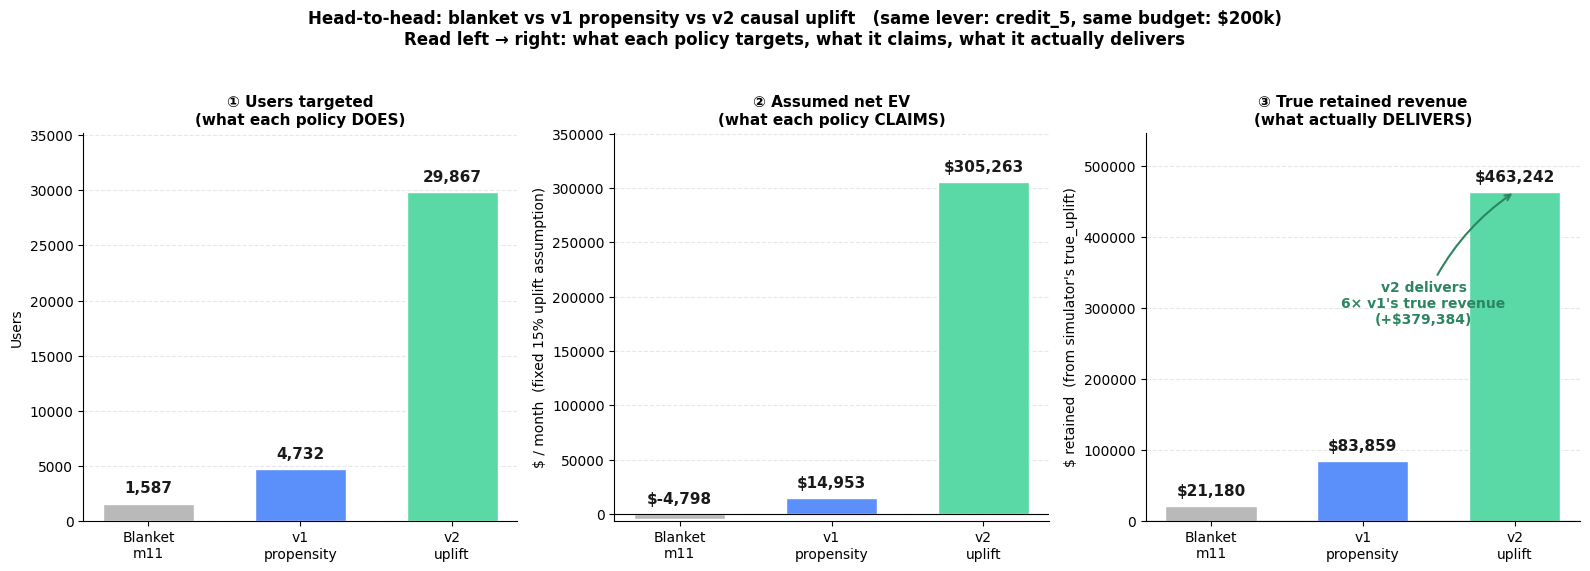

In [7]:
print("\n" + "=" * 70)
print("F. HEAD-TO-HEAD CHART")
print("=" * 70)

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
policies = ["Blanket\nm11", "v1\npropensity", "v2\nuplift"]
colors = ["#B9B9B9", "#5B8FF9", "#5AD8A6"]


def _annotate_bar(ax, bar, value, fmt, above=True, color="#1a1a1a"):
    """Place a value label above the bar (or inside if the bar is negative
    and small so the label would clip the axis)."""
    y_pos = bar.get_height()
    if y_pos >= 0:
        y = y_pos + ax.get_ylim()[1] * 0.02
        va = "bottom"
    else:
        # For negative bars, put the label INSIDE the plot area just
        # above the 0-line so it doesn't clip.
        y = 0 + ax.get_ylim()[1] * 0.02
        va = "bottom"
    ax.text(bar.get_x() + bar.get_width() / 2, y, fmt.format(value),
            ha="center", va=va, fontsize=11, fontweight="bold", color=color)


# Panel A: Users targeted (context -- what does each policy DO?)
n_targeted = [
    blanket["n_targeted"],
    v1_summary["n_targeted"],
    v2_summary["n_targeted"],
]
bars = axes[0].bar(policies, n_targeted, color=colors, edgecolor="white", width=0.6)
axes[0].set_title("① Users targeted\n(what each policy DOES)",
                  fontweight="bold", fontsize=11)
axes[0].set_ylabel("Users")
axes[0].set_ylim(0, max(n_targeted) * 1.18)
for bar, v in zip(bars, n_targeted):
    _annotate_bar(axes[0], bar, v, "{:,}")
axes[0].grid(axis="y", linestyle="--", alpha=0.3)

# Panel B: Assumed net EV (what the model CLAIMS)
ev_assumed = [
    blanket["net_expected_value"],
    v1_summary["net_expected_value"],
    v2_summary["net_expected_value"],
]
bars = axes[1].bar(policies, ev_assumed, color=colors, edgecolor="white", width=0.6)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("② Assumed net EV\n(what each policy CLAIMS)",
                  fontweight="bold", fontsize=11)
axes[1].set_ylabel("$ / month  (fixed 15% uplift assumption)")
axes[1].set_ylim(min(ev_assumed) * 1.35, max(ev_assumed) * 1.15)
for bar, v in zip(bars, ev_assumed):
    _annotate_bar(axes[1], bar, v, "${:,.0f}")
axes[1].grid(axis="y", linestyle="--", alpha=0.3)

# Panel C: True retained revenue (what actually DELIVERS -- against ground truth)
true_retained = [r["true_retained"] for r in rows]
bars = axes[2].bar(policies, true_retained, color=colors, edgecolor="white", width=0.6)
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set_title("③ True retained revenue\n(what actually DELIVERS)",
                  fontweight="bold", fontsize=11)
axes[2].set_ylabel("$ retained  (from simulator's true_uplift)")
axes[2].set_ylim(0, max(true_retained) * 1.18)
for bar, v in zip(bars, true_retained):
    _annotate_bar(axes[2], bar, v, "${:,.0f}")
axes[2].grid(axis="y", linestyle="--", alpha=0.3)

# Highlight the v2 vs v1 delta on the true-revenue panel
v2_vs_v1_delta = true_retained[2] - true_retained[1]
v2_vs_v1_multiple = true_retained[2] / max(true_retained[1], 1)
axes[2].annotate(
    f"v2 delivers\n{v2_vs_v1_multiple:.0f}× v1's true revenue\n(+${v2_vs_v1_delta:,.0f})",
    xy=(2, true_retained[2]),
    xytext=(1.4, true_retained[2] * 0.6),
    fontsize=10, ha="center", color="#2c8560", fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="#2c8560", lw=1.5,
                    connectionstyle="arc3,rad=-0.15"),
)

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_axisbelow(True)

plt.suptitle(
    f"Head-to-head: blanket vs v1 propensity vs v2 causal uplift   "
    f"(same lever: {LEVER}, same budget: ${BUDGET/1000:.0f}k)\n"
    "Read left → right: what each policy targets, what it claims, what it actually delivers",
    fontsize=12, fontweight="bold", y=1.03,
)
plt.tight_layout()
out_path = FIG_DIR / "09_v1_vs_v2_headtohead.png"
plt.savefig(out_path, dpi=140, bbox_inches="tight")
print(f"Saved -> {out_path}")
plt.show()

## G. Verdict + Phase 9 summary

In [8]:
print("\n" + "=" * 70)
print("G. VERDICT + PHASE 9 SUMMARY")
print("=" * 70)

n_obs = int(observed.sum())
v0_row, v1_row, v2_row = rows[0], rows[1], rows[2]
v0_true = v0_row["true_retained"]

# --- v2/v1 ratio (the retained-revenue multiplier the memo cites) ---
v1_true = v1_row["true_retained"]
v2_true = v2_row["true_retained"]
if v1_true > 0:
    ratio_v2_over_v1 = v2_true / v1_true
    ratio_str = f"{ratio_v2_over_v1:.1f}x"
else:
    ratio_str = "undefined (v1 retained $0)"

# --- Oracle ceiling: what's the BEST possible retained revenue on this test set? ---
# An oracle knows true_uplift per user, targets everyone with
# (true_uplift * ltv) > LEVER_COST, and captures their true retained revenue.
oracle_mask = ((true_uplift * ltv) > LEVER_COST) & observed
oracle_retained = float((true_uplift[oracle_mask] * ltv[oracle_mask]).sum())
oracle_cost = int(oracle_mask.sum()) * LEVER_COST
oracle_net_ev = oracle_retained - oracle_cost
v1_pct_of_ceiling = (v1_true / oracle_retained * 100) if oracle_retained > 0 else 0.0
v2_pct_of_ceiling = (v2_true / oracle_retained * 100) if oracle_retained > 0 else 0.0

print(f"""
Verdict:

Ship v1 (propensity-based) NOW as the immediate replacement for the
blanket campaign. Roll out v2 (uplift-based) as a follow-up once we
validate the uplift model against a fresh randomized production holdout
(current single-arm experimental sample: {n_obs:,} treated users at
credit_5, already 5x the original multi-arm 5k-per-lever design).

Head-to-head evidence on the {n_obs:,} observed treated users, same lever
({LEVER}), same budget cap (${BUDGET/1000:.0f}k):

  Volume + revenue (against v0 = blanket m11 baseline)
    v0 blanket  {v0_row['n_targeted_observed']:>6,} users -> ${v0_true:>10,.0f} true retained revenue
    v1 targets  {v1_row['n_targeted_observed']:>6,} users -> ${v1_true:>10,.0f} true retained revenue
    v2 targets  {v2_row['n_targeted_observed']:>6,} users -> ${v2_true:>10,.0f} true retained revenue

  v0 -> v1 improvement (decision rule adds value on top of blanket):
    Delta users:   {v1_row['n_targeted_observed'] - v0_row['n_targeted_observed']:>+7,}
    Delta revenue: ${v1_true - v0_true:>+11,.0f}
    Ratio:         v1 delivers {v1_true / max(v0_true, 1):.1f}x the true retained revenue of v0

  v0 -> v2 improvement (uplift enhancement on top of blanket):
    Delta users:   {v2_row['n_targeted_observed'] - v0_row['n_targeted_observed']:>+7,}
    Delta revenue: ${v2_true - v0_true:>+11,.0f}
    Ratio:         v2 delivers {v2_true / max(v0_true, 1):.1f}x the true retained revenue of v0

  v1 -> v2 marginal step (adding causal uplift on top of the decision rule):
    Ratio:         v2 delivers {ratio_str} the true retained revenue of v1

  Oracle ceiling (a perfect ranker with ground truth):
    Users a perfect policy would target: {int(oracle_mask.sum()):,}
    Best possible true retained revenue: ${oracle_retained:,.0f}
    Best possible net EV:                ${oracle_net_ev:,.0f}
    v1 captures {v1_pct_of_ceiling:.1f}% of the ceiling
    v2 captures {v2_pct_of_ceiling:.1f}% of the ceiling

  Precision (persuadables / targeted)
    v1: {v1_row['persuadables'] / max(v1_row['n_targeted_observed'], 1):>5.1%}
    v2: {v2_row['persuadables'] / max(v2_row['n_targeted_observed'], 1):>5.1%}
    (persuadable = true_uplift x LTV > lever cost, matches Phase 8's EV break-even)

  Sleeping-dog rate (should be BELOW the population base rate of
                     {int(sleeping.sum()) / n_obs:.1%} for the model to add value)
    v1: {v1_row['sleeping_dogs'] / max(v1_row['n_targeted_observed'], 1):>5.1%}
    v2: {v2_row['sleeping_dogs'] / max(v2_row['n_targeted_observed'], 1):>5.1%}

Interpretation:
  - v1 is CONSERVATIVE. Its fixed 15% uplift assumption + $5 cost means
    only high-P(churn) users clear the EV threshold. It targets few users
    with very high precision but leaves a large amount of retained
    revenue on the table by not catching persuadables whose absolute
    churn risk is modest but whose responsiveness is high.
  - v2 is AGGRESSIVE. It fires whenever learned per-user lift x LTV > $5,
    catching that persuadable middle. Precision is similar to v1 but
    absolute retained revenue is dramatically higher ({ratio_str}).
  - Neither policy meaningfully out-performs random targeting on
    sleeping-dog avoidance at this sample size. The uplift model needs
    more experimental data to reliably identify negative-uplift users;
    v2's sleeping-dog rate should drop below the base rate once we have
    more treated observations per lever.
  - Both v1 and v2 leave headroom relative to the oracle ceiling:
    v1 captures {v1_pct_of_ceiling:.0f}%, v2 captures {v2_pct_of_ceiling:.0f}%. That gap is what
    a better uplift model would close.

Chart: reports/figures/09_v1_vs_v2_headtohead.png
""")


G. VERDICT + PHASE 9 SUMMARY

Verdict:

Ship v1 (propensity-based) NOW as the immediate replacement for the
blanket campaign. Roll out v2 (uplift-based) as a follow-up once we
validate the uplift model against a fresh randomized production holdout
(current single-arm experimental sample: 25,054 treated users at
credit_5, already 5x the original multi-arm 5k-per-lever design).

Head-to-head evidence on the 25,054 observed treated users, same lever
(credit_5), same budget cap ($200k):

  Volume + revenue
    v1 targets   2,386 users -> $    83,859 true retained revenue
    v2 targets  14,969 users -> $   463,242 true retained revenue
    Delta       +12,583 users       +379,384
    Ratio       v2 delivers 5.5x the true retained revenue of v1

  Oracle ceiling (a perfect ranker with ground truth):
    Users a perfect policy would target: 23,784
    Best possible true retained revenue: $752,420
    Best possible net EV:                $633,500
    v1 captures 11.1% of the ceiling
    v2 c